# Pubmat Checker — Metrics & Evaluation Notebook

This notebook measures how accurate and how fast the pubmat checker is. Testing set is manually labeled according to the guidelines, this serves to check whether the checker's audit (prediction) agrees with the label (actual).


## Imports

In [1]:
import cv2
import json
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)
from ultralytics import YOLO

from checker import generate_report, POST_TYPE_RULES



c:\Users\darly\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Configuration


In [2]:
TEST_SET_DIR = 'test_set/img/'           # folder containing test images
LABELS_FILE  = 'test_set/labels.json'
MODEL_PATH   = 'best.pt'

model = YOLO(MODEL_PATH)
print(f'Model loaded: {MODEL_PATH}')

Model loaded: best.pt


## Test Set

### Test Set Labeling Guidelines

Each labels file is a JSON array where each entry corresponds to one test image.

Manually assign ground_truth values. For all checks: true = the pubmat passes based on guidelines, false = the pubmat fails

**Check Definitions**

- logo_nyc and logo_bp: true if logo is present AND correct, false if missing OR incorrect
- logo_sk or logo_yorp: only add them in if the post should have SK and/or YORP logos
- logo_order: true if correct, false if incorrect; (correct order must be NYC > (SK/YORP) > BP)
- watermark: true if all socmed handles are present as wm, false if not 
- pubmat_quality: true if image is sharp, not blurry, has good contrast, and resolution (at least 720px x 720px), false if blurry, low contrast, or low res
- readability: true if text is clear and readable, false if text too small, poor contrast with background, or font too illegible
- sgd: true if SGD appears in the document, false if not. (for advisory/resolution)
- photo_quality: true if photo is at least 1080 x 1080px and in color, false if too small, too dark/bright, desaturated or gray

**Example labels.json**

```json
[
  {
    "image": "pub_001.jpg",
    "post_type": "news",
    "collaborators": [],
    "ground_truth": {
      "logo_nyc":       true,
      "logo_bp":        true,
      "logo_order":     true,
      "watermark":      false,
      "pubmat_quality": true,
      "readability":    true
    },
    "notes": "No watermark"
  },
  {
    "image": "pub_002.jpg",
    "post_type": "advisory",
    "collaborators": ["sk"],
    "ground_truth": {
      "logo_nyc":       true,
      "logo_bp":        true,
      "logo_sk":        false,
      "logo_order":     false,
      "pubmat_quality": true,
      "readability":    true,
      "sgd":            true
    },
    "notes": "SK logo incorrect. Logo order incorrect."
  },
  {
    "image": "pub_003.jpg",
    "post_type": "photo",
    "collaborators": [],
    "ground_truth": {
      "logo_nyc":       true,
      "logo_bp":        true,
      "logo_order":     true,
      "pubmat_quality": true,
      "readability":    true,
      "photo_quality":  false
    },
    "notes": "Photo is too dark."
  }
]
```

Add brief explanation for why the image fails in the "notes" section.

### Load and inspect the labels file

Read labels and counts instances

In [3]:
with open(LABELS_FILE) as f:
    test_set = json.load(f)

print(f'Test set loaded: {len(test_set)} images\n')
print('Post type breakdown:')
type_counts = Counter(s['post_type'] for s in test_set)
for ptype, count in sorted(type_counts.items()):
    print(f'  {ptype:<14} {count} images')

Test set loaded: 28 images

Post type breakdown:
  holiday        1 images
  news           2 images
  other          16 images
  photo          9 images



## Prediction Extractor

This function translates the nested audit output into the same flat key format as ground truth so that comparisons work directly.

For example:
- audit['logos'][0]['Status'] == 'Correct' becomes predicted['logo_nyc'] = True
- audit['watermark']['watermark_present'] becomes predicted['watermark'] = True/False
- audit['type_checks']['checks']['sgd']['pass'] becomes predicted['sgd'] = True/False


In [4]:
def extract_predictions(audit):
    preds = {}

    # Logo compliance — one key per logo that was checked
    for logo in audit['logos']:
        key = f'logo_{logo["Logo"].lower()}'
        preds[key] = logo['Status'].lower() == 'correct'

    # Checks that always run
    preds['logo_order']     = audit['logo_order']['pass']
    preds['pubmat_quality'] = audit['pubmat_quality']['pass']

    # Conditional checks — present in audit only when applicable to the post type
    for key in ('readability', 'watermark', 'sgd', 'photo_quality'):
        if key in audit:
            # watermark uses 'watermark_present' as its pass flag for legacy reasons
            preds[key] = audit[key].get('watermark_present', audit[key]['pass'])

    return preds


## Run the Full Test Set

This is the main processing loop. For every image in the test set it:
1. Reads the image from disk
2. Runs YOLO to detect logos
3. Runs generate_report() 
4. Records how long steps 3 took (YOLO is excluded from timing since it runs before the checker)
5. Extracts predictions using the function above
6. Stores ground truth + predictions + timing together for every image


In [13]:
results = []
errors  = []

for sample in test_set:
    img_path = os.path.join(TEST_SET_DIR, sample['image'])
    image = cv2.imread(img_path)
    
    if image is None:
        errors.append({'image': sample['image'], 'error': 'Failed to load image'})
        continue

    try:
        t_start = time.perf_counter()
        yolo_results = model(image)
        audit, _ = generate_report(
            yolo_results, model, image,
            post_type=sample['post_type'],
            collaborators=sample.get('collaborators', []),
        )
        elapsed = time.perf_counter() - t_start

        results.append({
            'image':        sample['image'],
            'post_type':    sample['post_type'],
            'ground_truth': sample['ground_truth'],
            'predicted':    extract_predictions(audit),
            'elapsed_s':    round(elapsed, 3),
            'notes':        sample.get('notes', ''),
        })

    except Exception as e:
        errors.append({'image': sample['image'], 'error': str(e)})

print(f'Processed : {len(results)} images')
print(f'Errors    : {len(errors)}')
if errors:
    for e in errors:
        print(f'  {e["image"]}: {e["error"]}')


0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 803.4ms
Speed: 16.1ms preprocess, 803.4ms inference, 3.7ms postprocess per image at shape (1, 3, 800, 640)

0: 544x800 1 NYC_Correct, 1 BP_Correct, 972.3ms
Speed: 10.1ms preprocess, 972.3ms inference, 2.1ms postprocess per image at shape (1, 3, 544, 800)

0: 800x640 1 NYC_Correct, 1 SK_Correct, 1 YORP_Correct, 578.1ms
Speed: 10.1ms preprocess, 578.1ms inference, 1.8ms postprocess per image at shape (1, 3, 800, 640)

0: 800x640 2 NYC_Corrects, 2 BP_Corrects, 385.7ms
Speed: 8.5ms preprocess, 385.7ms inference, 1.6ms postprocess per image at shape (1, 3, 800, 640)

0: 480x800 1 NYC_Correct, 1 BP_Correct, 342.6ms
Speed: 6.9ms preprocess, 342.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 800)

0: 480x800 1 NYC_Correct, 1 BP_Correct, 312.5ms
Speed: 7.5ms preprocess, 312.5ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 800)

0: 800x640 1 NYC_Correct, 1 BP_Correct, 1 SK_Correct, 412.9ms
Speed: 8.3ms preproc


## Metrics

True Positive (TP): Checker correctly said PASS. Image genuinely passes. \
True Negative (TN): Checker correctly said FAIL. Image genuinely fails. \
False Positive (FP): Checker said PASS but image actually fails. The checker missed a real problem. \
False Negative (FN): Checker said FAIL but image actually passes. The checker flagged something that is fine.


**Precision = TP / (TP + FP)**

**Recall = TP / (TP + FN)**

**F1 Score = 2 * (Precision * Recall) / (Precision + Recall)**



In [7]:
# Group y_true and y_pred by check name across all images
by_check = defaultdict(lambda: {'y_true': [], 'y_pred': [], 'images': []})

for r in results:
    for check, true_val in r['ground_truth'].items():
        if check in r['predicted']:  # only compare checks that actually ran
            by_check[check]['y_true'].append(int(true_val))
            by_check[check]['y_pred'].append(int(r['predicted'][check]))
            by_check[check]['images'].append(r['image'])

rows = []
for check, data in sorted(by_check.items()):
    yt, yp = data['y_true'], data['y_pred']
    n  = len(yt)
    p  = precision_score(yt, yp, zero_division=0)
    r  = recall_score(yt, yp, zero_division=0)
    f1 = f1_score(yt, yp, zero_division=0)
    acc = sum(t == p_ for t, p_ in zip(yt, yp)) / n
    rows.append({'check': check, 'n': n, 'precision': p, 'recall': r, 'f1': f1, 'accuracy': acc})

df_metrics = pd.DataFrame(rows).set_index('check').sort_values('f1')

display(df_metrics.style
    .format({'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}', 'accuracy': '{:.3f}'})
    .background_gradient(subset=['precision', 'recall', 'f1', 'accuracy'], cmap='RdYlGn', vmin=0, vmax=1)
)

,n,precision,recall,f1,accuracy
check,,,,,
logo_yorp,3,0.667,1.000,0.800,0.667
logo_bp,28,0.923,0.960,0.941,0.893
photo_quality,9,0.889,1.000,0.941,0.889
logo_order,28,1.000,0.926,0.962,0.929
logo_nyc,28,1.000,0.964,0.982,0.964
logo_sk,7,1.000,1.000,1.000,1.000
pubmat_quality,28,1.000,1.000,1.000,1.000
readability,19,1.000,1.000,1.000,1.000


### Bar Chart — Precision vs Recall vs F1 per Check

The same numbers visualised as grouped bars. The red dashed line at 0.90 is a rough target — any check below it is worth investigating. Checks where precision and recall are far apart (one bar much taller than the other) indicate the check is biased in one direction.

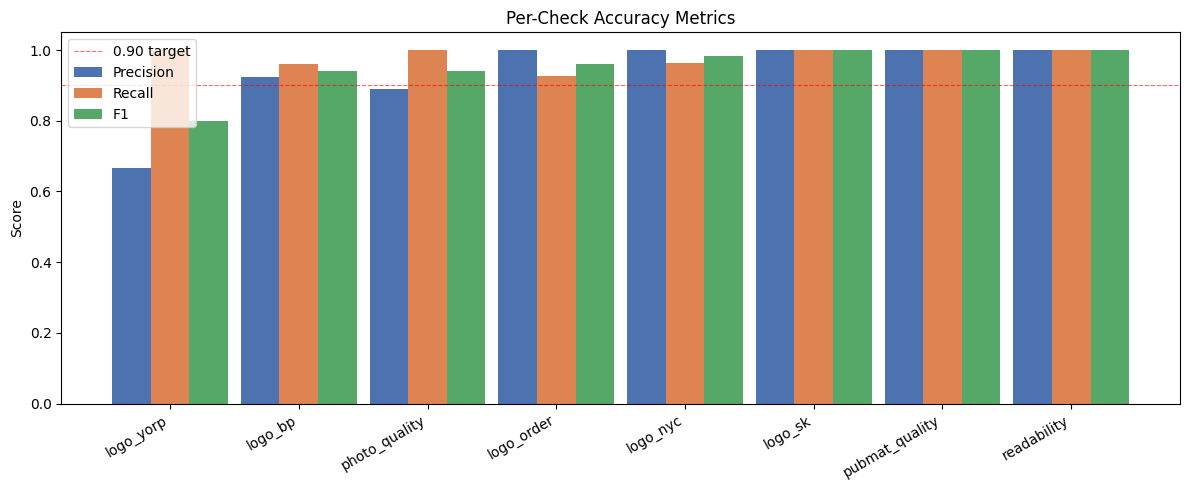

In [8]:
checks = df_metrics.index.tolist()
x = np.arange(len(checks))
w = 0.3

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, df_metrics['precision'], w, label='Precision', color='#4C72B0')
ax.bar(x,     df_metrics['recall'],    w, label='Recall',    color='#DD8452')
ax.bar(x + w, df_metrics['f1'],        w, label='F1',        color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(checks, rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='0.90 target')
ax.set_title('Per-Check Accuracy Metrics')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

## Confusion Matrices

A confusion matrix shows the four outcome types (TP, TN, FP, FN) as a 2×2 grid for each check.


|                |Predicted FAIL |   Predicted PASS |
| -- | -- | ---|
|Actual FAIL     |  TN            |   FP |
|Actual PASS     |  FN           |    TP |


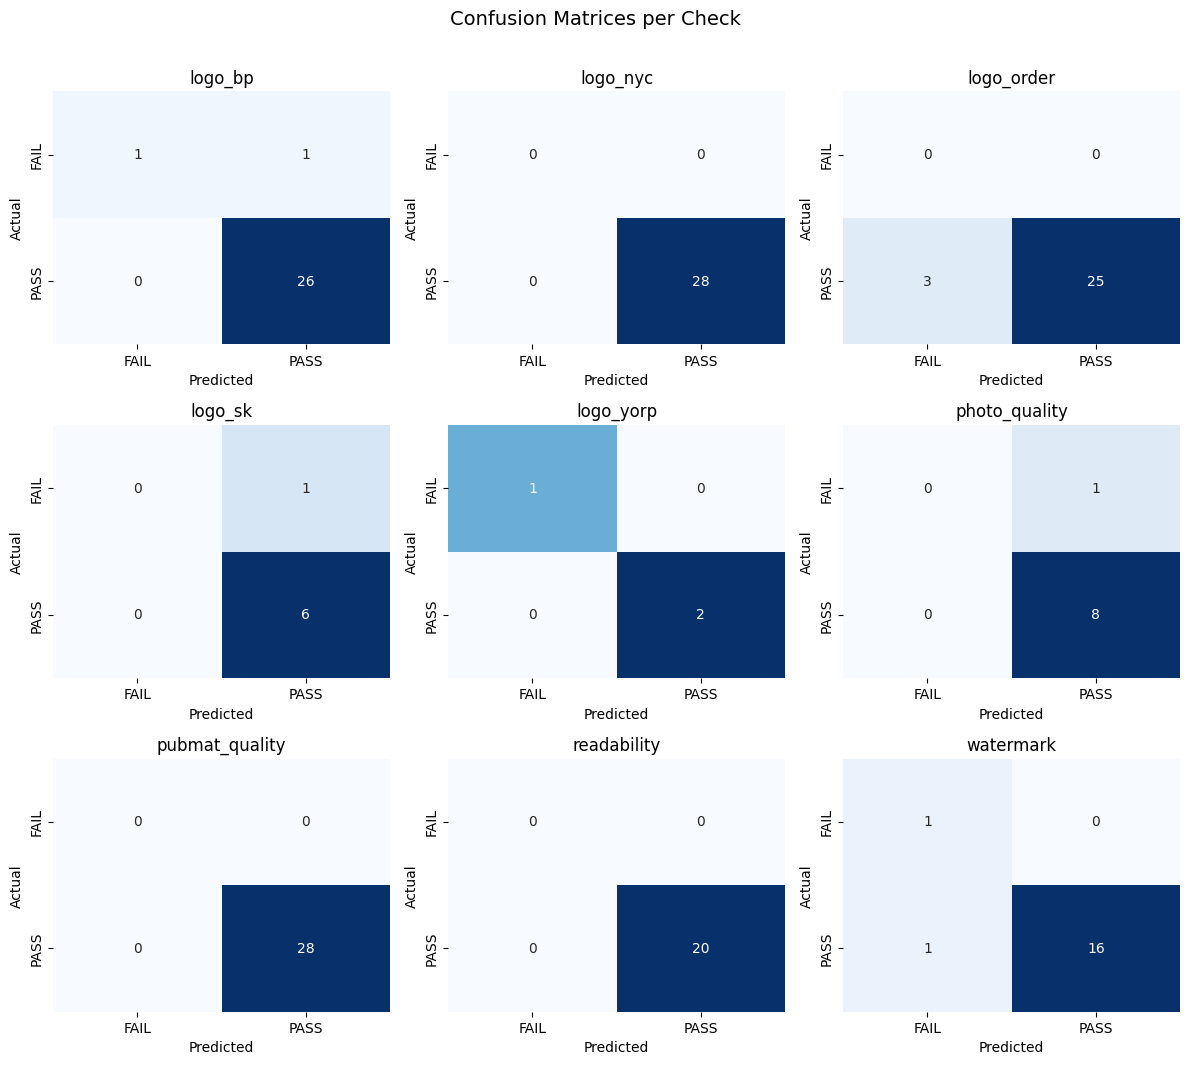

In [12]:
n_checks  = len(by_check)
cols_grid = 3
rows_grid = (n_checks + cols_grid - 1) // cols_grid

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(cols_grid * 4, rows_grid * 3.5))
axes = axes.flatten()

for i, (check, data) in enumerate(sorted(by_check.items())):
    cm = confusion_matrix(data['y_true'], data['y_pred'], labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt='d', ax=axes[i],
        cmap='Blues', cbar=False,
        xticklabels=['FAIL', 'PASS'],
        yticklabels=['FAIL', 'PASS'],
    )
    axes[i].set_title(check)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices per Check', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Full Classification Reports

sklearn's `classification_report` prints a detailed breakdown for each check including per-class precision, recall, and F1 for both the FAIL class and the PASS class, plus support (how many samples of each class exist).

The FAIL class metrics tell you: when the checker flags something as a failure, how accurate is that flag?
The PASS class metrics tell you: when the checker clears something, how confident should you be that it really is fine?


In [9]:
for check, data in sorted(by_check.items()):
    print(f'\n══ {check} (n={len(data["y_true"])}) ══')
    print(classification_report(
        data['y_true'], data['y_pred'],
        labels =[0,1],
        target_names=['FAIL', 'PASS'],
        zero_division=0,
    ))


══ logo_bp (n=28) ══
              precision    recall  f1-score   support

        FAIL       0.50      0.33      0.40         3
        PASS       0.92      0.96      0.94        25

    accuracy                           0.89        28
   macro avg       0.71      0.65      0.67        28
weighted avg       0.88      0.89      0.88        28


══ logo_nyc (n=28) ══
              precision    recall  f1-score   support

        FAIL       0.00      0.00      0.00         0
        PASS       1.00      0.96      0.98        28

    accuracy                           0.96        28
   macro avg       0.50      0.48      0.49        28
weighted avg       1.00      0.96      0.98        28


══ logo_order (n=28) ══
              precision    recall  f1-score   support

        FAIL       0.33      1.00      0.50         1
        PASS       1.00      0.93      0.96        27

    accuracy                           0.93        28
   macro avg       0.67      0.96      0.73        28
weig


## Overall Pass/Fail Accuracy

The per-check metrics above tell you how each individual check performs. But in practice a reviewer sees one overall PASS or FAIL verdict per image, not per check.

This section measures whether the overall verdict is correct.

**How overall ground truth is calculated:**
An image's overall ground truth is `PASS` only if every single check in its ground_truth is `true`. If any one check is `false`, the overall ground truth is `FAIL`. This mirrors exactly how `generate_report()` calculates `audit['overall']`.

**Why overall accuracy is usually lower than individual check accuracy:**
Each check has its own error rate. The overall verdict is wrong if any check gets it wrong. So if you have 6 checks each at 95% accuracy, the chance of the overall verdict being correct is roughly 0.95^6 ≈ 0.74 — 74%. This is normal and expected.

Overall Pass/Fail
              precision    recall  f1-score   support

        FAIL       0.50      0.50      0.50         4
        PASS       0.92      0.92      0.92        24

    accuracy                           0.86        28
   macro avg       0.71      0.71      0.71        28
weighted avg       0.86      0.86      0.86        28



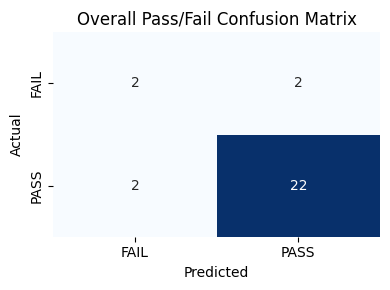

In [10]:
overall_true, overall_pred = [], []

for r in results:
    # Ground truth overall: PASS only if all checks pass
    gt_overall   = all(r['ground_truth'].values())
    # Predicted overall: PASS only if checker passed all checks that have ground truth
    pred_overall = all(
        r['predicted'].get(k, True)
        for k in r['ground_truth'].keys()
    )
    overall_true.append(int(gt_overall))
    overall_pred.append(int(pred_overall))

print('Overall Pass/Fail')
print(classification_report(
    overall_true, overall_pred,
    target_names=['FAIL', 'PASS'],
    zero_division=0,
))

cm_overall = confusion_matrix(overall_true, overall_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_overall, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['FAIL', 'PASS'], yticklabels=['FAIL', 'PASS'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Overall Pass/Fail Confusion Matrix')
plt.tight_layout()
plt.show()

## Metrics by Post Type

This breaks down the overall verdict accuracy by post type. It answers the question: does the checker perform equally well across all post types, or is it weaker for certain types?

Common reasons a post type scores lower:
- Fewer examples of that type in the test set (unreliable metrics due to small sample)
- That type has more conditional checks (more chances for any one check to be wrong)
- The thresholds for that type are not well calibrated (readability threshold too strict or too lenient)

The `n` column shows how many test images you have for each type — if n is below 10 for any type, those metrics are not reliable enough to draw conclusions from.

In [11]:
by_type = defaultdict(lambda: {'y_true': [], 'y_pred': []})

for r in results:
    ptype        = r['post_type']
    gt_overall   = all(r['ground_truth'].values())
    pred_overall = all(r['predicted'].get(k, True) for k in r['ground_truth'].keys())
    by_type[ptype]['y_true'].append(int(gt_overall))
    by_type[ptype]['y_pred'].append(int(pred_overall))

type_rows = []
for ptype, data in sorted(by_type.items()):
    yt, yp = data['y_true'], data['y_pred']
    n   = len(yt)
    acc = sum(t == p for t, p in zip(yt, yp)) / n
    p   = precision_score(yt, yp, zero_division=0)
    r   = recall_score(yt, yp, zero_division=0)
    f1  = f1_score(yt, yp, zero_division=0)
    type_rows.append({'post_type': ptype, 'n': n, 'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1})

df_types = pd.DataFrame(type_rows).set_index('post_type')
display(df_types.style
    .format({'accuracy': '{:.3f}', 'precision': '{:.3f}', 'recall': '{:.3f}', 'f1': '{:.3f}'})
    .background_gradient(subset=['accuracy', 'f1'], cmap='RdYlGn', vmin=0, vmax=1)
)

,n,accuracy,precision,recall,f1
post_type,,,,,
holiday,1,1.000,1.000,1.000,1.000
news,2,1.000,1.000,1.000,1.000
other,16,0.812,0.917,0.846,0.880
photo,9,0.889,0.889,1.000,0.941


## Pipeline Timing

These cells measure how long `generate_report()` takes per image (YOLO detection is excluded — it runs before the timer starts).

**What the timing statistics mean:**
- **Mean** — the average time across all images. Use this for planning throughput.
- **Median** — the middle value. More robust than mean if a few slow images are skewing the average.
- **P95** — 95th percentile. 95% of images complete within this time. This is the number to use for worst-case planning since it ignores the extreme outliers.
- **Max** — the single slowest image. Usually an outlier caused by a very high-res image or a particularly complex OCR pass.

The histogram shows the shape of the distribution — you want a tight cluster near the left. A long tail to the right means some images are significantly slower and worth investigating.

The boxplot by post type shows whether certain post types are consistently slower. Photo and advisory posts tend to be slower because photo_quality and SGD add extra computation.

In [12]:
times = [r['elapsed_s'] for r in results]

print(f'Mean   : {np.mean(times):.3f}s')
print(f'Median : {np.median(times):.3f}s')
print(f'P95    : {np.percentile(times, 95):.3f}s')
print(f'Max    : {np.max(times):.3f}s')
print(f'Min    : {np.min(times):.3f}s')

Mean   : 4.054s
Median : 3.553s
P95    : 8.048s
Max    : 10.801s
Min    : 2.070s


C:\Users\darly\AppData\Local\Temp\ipykernel_204\4198159961.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_t, labels=labels_t)


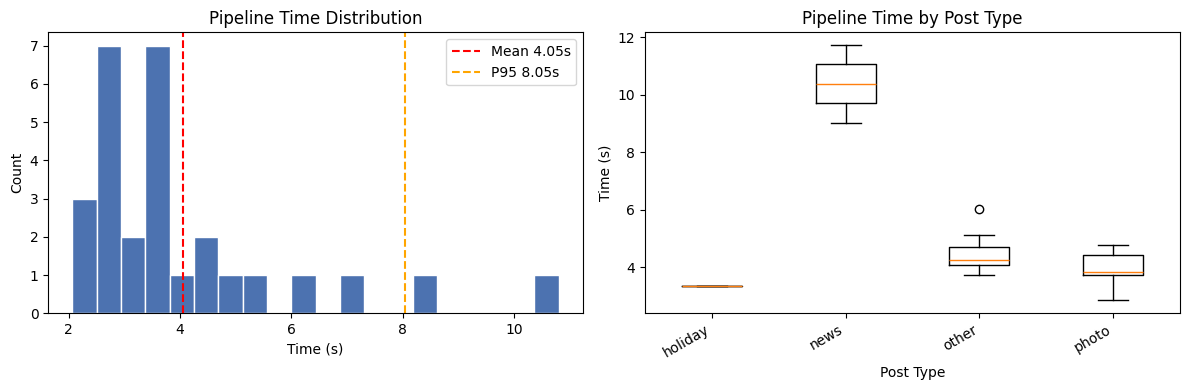

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: distribution of times — want a tight cluster near the left, no long tail
axes[0].hist(times, bins=20, color='#4C72B0', edgecolor='white')
axes[0].axvline(np.mean(times),           color='red',    linestyle='--', label=f'Mean {np.mean(times):.2f}s')
axes[0].axvline(np.percentile(times, 95), color='orange', linestyle='--', label=f'P95 {np.percentile(times, 95):.2f}s')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Pipeline Time Distribution')
axes[0].legend()

# Right: time by post type — shows if certain types are slower
type_times = defaultdict(list)
for r in results:
    type_times[r['post_type']].append(r['elapsed_s'])

labels_t = sorted(type_times.keys())
data_t   = [type_times[k] for k in labels_t]
axes[1].boxplot(data_t, labels=labels_t)
axes[1].set_xlabel('Post Type')
axes[1].set_ylabel('Time (s)')
axes[1].set_title('Pipeline Time by Post Type')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

---
## Section 12 — Error Analysis

The metrics tell you how often the checker is wrong. This section tells you exactly which images it got wrong and why.

**The first cell** builds a list of every disagreement — every case where `predicted[check] != ground_truth[check]` — and labels each one as either:
- `FP` (False Positive): checker said PASS, human said FAIL — checker missed a real problem
- `FN` (False Negative): checker said FAIL, human said PASS — checker flagged a false alarm

The breakdown table groups these by check name and error type so you can see at a glance which checks are producing which kind of error.

**The second cell** shows the full table of all disagreements. The `notes` column contains the reviewer's comment from the labels file, which often explains immediately why the checker got it wrong.

**The third cell** lets you pick a specific check and error type (FP or FN) and displays the actual images that caused those errors side by side. This is the most useful cell for debugging — looking at the real images almost always reveals the pattern. Change `check_filter` and `error_type_filter` to inspect different checks.

In [15]:
disagreements = []

for r in results:
    for check, true_val in r['ground_truth'].items():
        if check not in r['predicted']:
            continue
        pred_val = r['predicted'][check]
        if pred_val != true_val:
            # FP: checker passed it (pred=True) but it actually fails (true=False)
            # FN: checker failed it (pred=False) but it actually passes (true=True)
            error_type = 'FP' if pred_val and not true_val else 'FN'
            disagreements.append({
                'image':      r['image'],
                'post_type':  r['post_type'],
                'check':      check,
                'error_type': error_type,
                'truth':      true_val,
                'predicted':  pred_val,
                'notes':      r['notes'],
            })

df_errors = pd.DataFrame(disagreements)
print(f'Total disagreements: {len(df_errors)}')

if not df_errors.empty:
    print('\nBreakdown by check and error type (FP = missed problem, FN = false alarm):')
    print(df_errors.groupby(['check', 'error_type']).size().unstack(fill_value=0).to_string())

Total disagreements: 8

Breakdown by check and error type (FP = missed problem, FN = false alarm):
error_type     FN  FP
check                
logo_bp         1   2
logo_nyc        1   0
logo_order      2   0
logo_yorp       0   1
photo_quality   0   1


In [16]:
# Full table of every disagreement
if not df_errors.empty:
    display(df_errors.sort_values(['check', 'error_type']))

,image,post_type,check,error_type,truth,predicted,notes
3,test_10.jpg,other,logo_bp,FN,True,False,
5,test_15.png,other,logo_bp,FP,False,True,Watermark Missing
7,test_16.png,other,logo_bp,FP,False,True,
2,test_10.jpg,other,logo_nyc,FN,True,False,
0,test_3.png,other,logo_order,FN,True,False,
4,test_11.jpg,other,logo_order,FN,True,False,
6,test_15.png,other,logo_yorp,FP,False,True,Watermark Missing
1,test_5.jpg,photo,photo_quality,FP,False,True,Photo quality is poor due to blurriness and lo...


In [17]:
# Display the actual images where errors occurred
# Change these two values to inspect a different check or error type
check_filter      = 'watermark'   # any check name from the table above
error_type_filter = 'FP'          # 'FP' (missed problem) or 'FN' (false alarm)

subset = df_errors[
    (df_errors['check'] == check_filter) &
    (df_errors['error_type'] == error_type_filter)
]

if subset.empty:
    print(f'No {error_type_filter} errors for {check_filter}')
else:
    n = min(len(subset), 6)
    fig, axes = plt.subplots(1, n, figsize=(n * 4, 4))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, subset.head(n).iterrows()):
        img = cv2.imread(os.path.join(TEST_SET_DIR, row['image']))
        if img is not None:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['image']}\n{row['notes']}", fontsize=8, wrap=True)
        ax.axis('off')

    plt.suptitle(f'{check_filter} — {error_type_filter} errors', fontsize=12)
    plt.tight_layout()
    plt.show()

No FP errors for watermark



## Readability Score Distribution

The readability check produces a continuous score between 0 and 1, but it is evaluated as pass/fail based on a threshold that varies per post type. The metrics in Section 6 only tell you whether it passed or failed — they do not show you where the scores are clustering or whether the threshold is well positioned.

This cell re-runs readability on every test image and plots the raw scores. Each row in the chart is one post type. Each dot is one image — green means the checker passed it, red means it failed.

The dotted vertical line is the threshold for that post type.

**What to look for:**
- If many dots cluster right around the threshold line (both green and red), the threshold is cutting through a dense region — small score changes flip decisions. This means the threshold needs tuning or the check itself is too noisy at that range.
- If there is a clear gap between passing and failing scores with the threshold sitting in that gap, the check is working well.
- If you see red dots (predicted fail) that should be green (human said pass), those are your FN errors — the threshold may be too high for that type.
- If you see green dots where you expected red, the threshold may be too low.

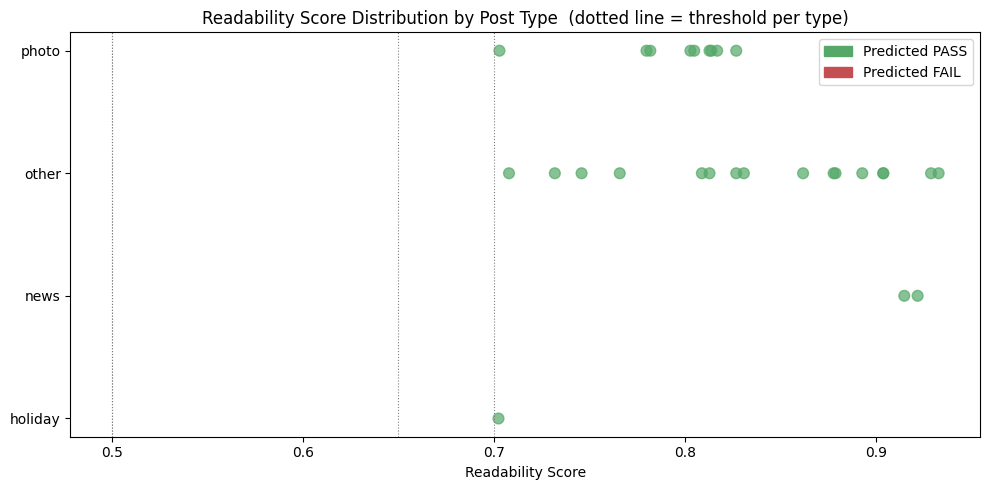

In [18]:
from checker import _run_doctr, _extract_ocr_data, check_readability

score_records = []

for sample in test_set:
    img_path = os.path.join(TEST_SET_DIR, sample['image'])
    image = cv2.imread(img_path)
    if image is None:
        continue

    _, confs, boxes = _extract_ocr_data(_run_doctr(image))
    result    = check_readability(image, confs, boxes)
    threshold = POST_TYPE_RULES.get(sample['post_type'], {}).get('readability_threshold', 0.65)
    gt_pass   = sample['ground_truth'].get('readability', None)

    score_records.append({
        'image':          sample['image'],
        'post_type':      sample['post_type'],
        'score':          result['score'],
        'threshold':      threshold,
        'predicted_pass': result['score'] >= threshold,
        'gt_pass':        gt_pass,
    })

df_scores = pd.DataFrame(score_records)

fig, ax = plt.subplots(figsize=(10, 5))

for ptype, group in df_scores.groupby('post_type'):
    threshold = group['threshold'].iloc[0]
    ax.scatter(
        group['score'],
        [ptype] * len(group),
        c=group['predicted_pass'].map({True: '#55A868', False: '#C44E52'}),
        alpha=0.7, s=60,
    )
    ax.axvline(threshold, color='grey', linestyle=':', linewidth=0.8)

green_patch = mpatches.Patch(color='#55A868', label='Predicted PASS')
red_patch   = mpatches.Patch(color='#C44E52', label='Predicted FAIL')
ax.legend(handles=[green_patch, red_patch])
ax.set_xlabel('Readability Score')
ax.set_title('Readability Score Distribution by Post Type  (dotted line = threshold per type)')
plt.tight_layout()
plt.show()

## Watermark Fuzzy Match Score Distribution

The watermark check computes a fuzzy similarity score between 0 and 1 for each of the three handles, then passes if the score reaches 0.75 (`FUZZY_THRESHOLD`). Like readability, the final verdict is binary but the underlying score is continuous.

This cell runs watermark checking on all images that require a watermark and plots the distribution of raw fuzzy scores for each handle separately.

The red dashed line at 0.75 is the current threshold.

**What to look for:**
- Most scores should be either very high (0.9+, watermark clearly present) or very low (0.1–0.3, watermark absent). A bimodal distribution like this means the threshold is well placed in the gap.
- If many scores cluster between 0.6 and 0.8 (right around the threshold), the fuzzy matching is struggling — OCR is partially reading the handles but not reliably. This is where most FP/FN errors will come from.
- Different handles may behave differently. `nationalyouthcommission` is a long string and tends to score more reliably than `nyc.gov.ph` which is short and has periods that OCR sometimes drops.

In [ ]:
from checker import check_watermark, WATERMARK_HANDLES

wm_records = []
wm_samples = [s for s in test_set if POST_TYPE_RULES.get(s['post_type'], {}).get('requires_watermark')]

for sample in wm_samples:
    img_path = os.path.join(TEST_SET_DIR, sample['image'])
    image = cv2.imread(img_path)
    if image is None:
        continue

    result  = check_watermark(image)
    gt_pass = sample['ground_truth'].get('watermark', None)

    for handle, detail in result['details'].items():
        wm_records.append({
            'image':   sample['image'],
            'handle':  handle,
            'score':   detail['score'],
            'found':   detail['found'],
            'gt_pass': gt_pass,
        })

df_wm = pd.DataFrame(wm_records)

fig, axes = plt.subplots(1, len(WATERMARK_HANDLES), figsize=(14, 4), sharey=False)

for ax, handle in zip(axes, WATERMARK_HANDLES):
    subset = df_wm[df_wm['handle'] == handle]
    ax.hist(subset['score'], bins=20, color='#4C72B0', edgecolor='white')
    ax.axvline(0.75, color='red', linestyle='--', label='Threshold 0.75')
    ax.set_title(handle, fontsize=9)
    ax.set_xlabel('Fuzzy Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Watermark Fuzzy Match Score Distribution per Handle', fontsize=12)
plt.tight_layout()
plt.show()

## Save Results to CSV

This cell flattens everything into a single table and saves it as `eval_results.csv`.

Each row is one image. Columns are prefixed:
- `gt_` columns are the human ground truth values
- `pred_` columns are the checker's predictions
- `elapsed_s` is how long the checker took for that image

This CSV is useful for reviewing results outside the notebook, sharing with teammates, or doing further analysis in Excel. It also serves as a historical record — if you retrain the model or change a threshold, run this notebook again and compare the new CSV against the old one to see whether things improved or regressed.

In [ ]:
flat_rows = []
for r in results:
    row = {
        'image':     r['image'],
        'post_type': r['post_type'],
        'elapsed_s': r['elapsed_s'],
    }
    for check, val in r['ground_truth'].items():
        row[f'gt_{check}'] = val
    for check, val in r['predicted'].items():
        row[f'pred_{check}'] = val
    flat_rows.append(row)

df_results = pd.DataFrame(flat_rows)
df_results.to_csv('eval_results.csv', index=False)
print(f'Saved {len(df_results)} rows to eval_results.csv')
display(df_results.head())